# Experto 3 — fusión de las cinco fuentes

El Experto 1 lee sólo `structured-prompt.json`. Este lee además todo lo que se
puede extraer de `prostate-biopsy-decision-clinical-data.json`: la analítica, la
serie de PSA, el informe radiológico (por extracción con detección de negación) y
las notas previas.

La pregunta que contesta este cuaderno es si **leer más fuentes mejora la
decisión**, y cuánto. La respuesta no se da por supuesta: se mide.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT))
DATA = ROOT.parent / "data_filtered" / "task1"
ART  = ROOT / "task_one" / "train" / "artifacts"

from chimera_experts.io import load_cases
from chimera_experts.expert_classifier import BiopsyExpert, weights_from_importance
from chimera_experts.uncertainty import ladder_table, reliability_table

e3 = BiopsyExpert.load(ROOT / "task_one" / "expert_three" / "model" / "expert_three.joblib")
e1 = BiopsyExpert.load(ROOT / "task_one" / "expert_one"   / "model" / "expert_one.joblib")
cases = load_cases(DATA, task=1)
labelled = [c for c in cases if c.has_label]
print(f"Experto 3: bloques {e3.blocks}, {len(e3.feature_names)} variables")
print(f"Experto 1: bloques {e1.blocks}, {len(e1.feature_names)} variables")

Experto 3: bloques ABD, 75 variables
Experto 1: bloques A, 39 variables


## 1. Qué extrae realmente el lector del informe radiológico

El bloque D no es una bolsa de palabras: es un extractor de conceptos con
detección de negación al estilo NegEx (Chapman et al. 2001). Cada concepto es
**ternario** — afirmado, negado, o no mencionado — porque "sin extensión
extracapsular" es evidencia y "no se menciona" no lo es.

In [2]:
from chimera_experts.features_radiology import extract as rad_extract
F = pd.DataFrame([rad_extract(c.clinical) for c in cases])
tern = [c for c in F.columns if c.startswith("rad_") and set(F[c].dropna().unique()) <= {0.0, 1.0}]
tab = pd.DataFrame({
    "afirmado":     (F[tern] == 1.0).sum(),
    "negado":       (F[tern] == 0.0).sum(),
    "no mencionado": F[tern].isna().sum(),
}).sort_values("afirmado", ascending=False)
display(tab)
print("\nHallazgo: en esta cohorte prácticamente no hay enfermedad localmente avanzada.")
print("La invasión de vesículas seminales y las adenopatías se reportan como ausentes")
print("en todos los casos que las mencionan, de modo que esas columnas no discriminan.")

,afirmado,negado,no mencionado
rad_has_measurement,185,10,0
rad_zone_peripheral,184,11,0
rad_dwi_restriction,175,15,5
rad_loc_mid,174,21,0
rad_dce_early_focal,137,9,49
rad_lesion_ge15mm,67,118,10
rad_adc_low,66,0,129
rad_loc_base,53,142,0
rad_t2_marked_hypo,38,0,157
rad_zone_transition,27,168,0



Hallazgo: en esta cohorte prácticamente no hay enfermedad localmente avanzada.
La invasión de vesículas seminales y las adenopatías se reportan como ausentes
en todos los casos que las mencionan, de modo que esas columnas no discriminan.


## 2. Ablación: qué aporta cada bloque

`ablation_blocks.csv` recorre las combinaciones de bloques con sentido clínico.
`ablation_leave_one_out.csv` quita un bloque cada vez del conjunto completo: si
quitarlo no baja el AUC, ese bloque es redundante con los demás.

,blocks,block_names,n_features,nan_rate,cv_auc,ci_lo,ci_hi,cv_balanced_accuracy,cv_brier,cv_ece
0,ABD,structured+labs+radiology_nlp,75,0.105,0.794,0.696,0.876,0.632,0.179,0.094
1,ABCD,structured+labs+psa_trend+radiology_nlp,94,0.084,0.790,0.683,0.873,0.632,0.184,0.074
2,AD,structured+radiology_nlp,58,0.123,0.787,0.689,0.872,0.657,0.181,0.070
3,ABCDE,structured+labs+psa_trend+radiology_nlp+notes,102,0.078,0.786,0.681,0.871,0.634,0.181,0.121
4,ACD,structured+psa_trend+radiology_nlp,77,0.093,0.785,0.684,0.869,0.661,0.185,0.058
5,ABDE,structured+labs+radiology_nlp+notes,83,0.095,0.783,0.681,0.864,0.648,0.180,0.087
6,BCDE,labs+psa_trend+radiology_nlp+notes,63,0.045,0.782,0.675,0.870,0.646,0.188,0.096
7,ACDE,structured+psa_trend+radiology_nlp+notes,85,0.084,0.777,0.670,0.864,0.630,0.183,0.095
8,AB,structured+labs,56,0.104,0.770,0.665,0.860,0.614,0.194,0.130
9,ABC,structured+labs+psa_trend,75,0.077,0.766,0.657,0.857,0.600,0.198,0.134


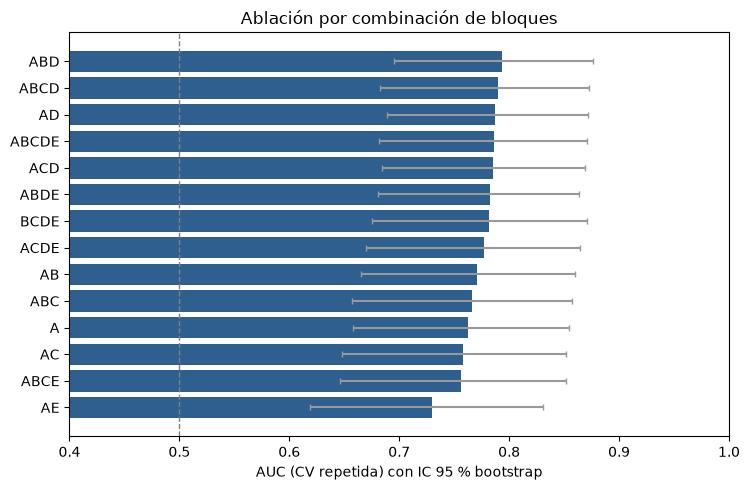

In [3]:
ab = pd.read_csv(ART / "ablation_blocks.csv")
display(ab.round(3))

fig, ax = plt.subplots(figsize=(7.6, 5))
a = ab.sort_values("cv_auc")
ax.barh(a["blocks"], a["cv_auc"], color="#2f5f8f",
        xerr=[a["cv_auc"] - a["ci_lo"], a["ci_hi"] - a["cv_auc"]], capsize=2, ecolor="#999")
ax.axvline(0.5, ls="--", c="grey", lw=1)
ax.set_xlim(0.4, 1.0); ax.set_xlabel("AUC (CV repetida) con IC 95 % bootstrap")
ax.set_title("Ablación por combinación de bloques")
plt.tight_layout(); plt.show()

,removed,removed_name,n_features,cv_auc,delta_auc,ci_lo,ci_hi,p_value
0,(none),conjunto completo,102,0.786,0.000,NaN,NaN,NaN
1,A,structured,63,0.782,-0.005,-0.046,0.036,0.812
2,B,labs,85,0.777,-0.009,-0.045,0.022,0.544
3,C,psa_trend,83,0.783,-0.004,-0.029,0.018,0.872
4,D,radiology_nlp,83,0.756,-0.030,-0.085,0.012,0.188
5,E,notes,94,0.790,0.004,-0.020,0.031,0.772


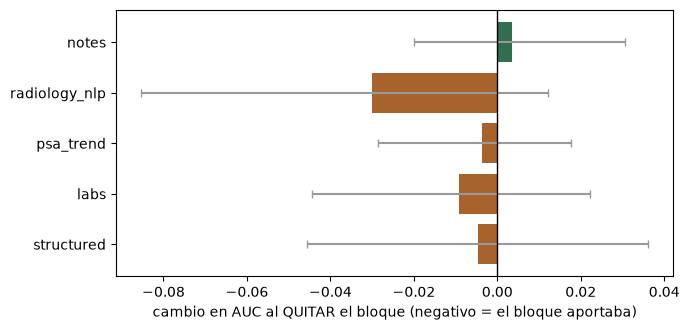

In [4]:
lo = pd.read_csv(ART / "ablation_leave_one_out.csv")
display(lo.round(3))
fig, ax = plt.subplots(figsize=(7, 3.4))
d = lo[lo["removed"] != "(none)"]
ax.barh(d["removed_name"], d["delta_auc"],
        xerr=[d["delta_auc"] - d["ci_lo"], d["ci_hi"] - d["delta_auc"]],
        color=["#a8632c" if v < 0 else "#2f6f4f" for v in d["delta_auc"]], capsize=3, ecolor="#999")
ax.axvline(0, c="k", lw=1)
ax.set_xlabel("cambio en AUC al QUITAR el bloque (negativo = el bloque aportaba)")
plt.tight_layout(); plt.show()

## 3. ¿Hace falta un experto sobre el vector neuronal de RM?

Se entrena una sonda lineal sobre el vector de 1024 dimensiones y se compara con
el escalar `cspca`, que ya viene resuelto en `structured-prompt.json` y procede
del detector de csPCa del propio reto.

,predictor,n,cv_auc,ci_lo,ci_hi
0,linear_probe_pca4,89,0.387,0.267,0.500
1,linear_probe_pca8,89,0.446,0.313,0.584
2,linear_probe_pca16,89,0.416,0.297,0.544
3,linear_probe_pca32,89,0.444,0.326,0.576
4,linear_probe_pca64,89,0.443,0.321,0.573
5,cspca_scalar_from_prompt,89,0.560,0.433,0.699


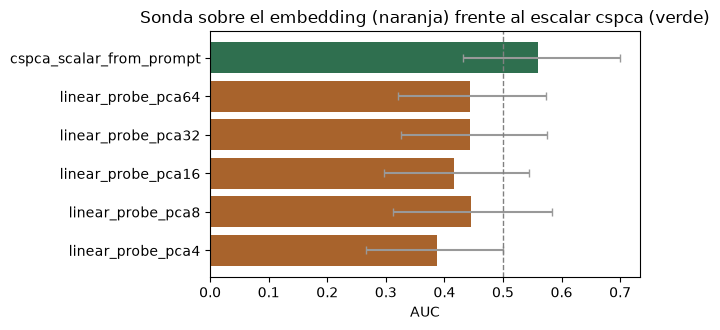

In [5]:
pr = pd.read_csv(ART / "embedding_probe.csv")
display(pr.round(3))
fig, ax = plt.subplots(figsize=(6.6, 3.4))
col = ["#2f6f4f" if "cspca" in n else "#a8632c" for n in pr["predictor"]]
ax.barh(pr["predictor"], pr["cv_auc"], xerr=[pr["cv_auc"] - pr["ci_lo"], pr["ci_hi"] - pr["cv_auc"]],
        color=col, capsize=3, ecolor="#999")
ax.axvline(0.5, ls="--", c="grey", lw=1); ax.set_xlabel("AUC")
ax.set_title("Sonda sobre el embedding (naranja) frente al escalar cspca (verde)")
plt.tight_layout(); plt.show()

## 4. Experto 3 frente a Experto 1

In [6]:
o1 = pd.read_csv(ART / "expert_one_oof.csv")
o3 = pd.read_csv(ART / "expert_three_oof.csv")
from chimera_experts.evaluation import metrics, paired_bootstrap
y = o1["y"].values
m1, m3 = metrics(y, o1["p_ensemble"].values), metrics(y, o3["p_ensemble"].values)
display(pd.DataFrame({"Experto 1 (bloque A)": m1, "Experto 3 (fusión)": m3}).round(3))
cmp = paired_bootstrap(y, o3["p_ensemble"].values, o1["p_ensemble"].values, "auc")
print(f"\nDiferencia de AUC (E3 - E1): {cmp['delta']:+.3f}  "
      f"IC 95 % [{cmp['ci_lo']:+.3f}, {cmp['ci_hi']:+.3f}]  p = {cmp['p_value']:.3f}")

,Experto 1 (bloque A),Experto 3 (fusión)
auc,0.778,0.811
ap,0.878,0.882
accuracy,0.681,0.736
balanced_accuracy,0.612,0.684
f1,0.779,0.810
sensitivity,0.911,0.911
specificity,0.314,0.457
ppv,0.680,0.729
npv,0.688,0.762
brier,0.195,0.186



Diferencia de AUC (E3 - E1): +0.033  IC 95 % [-0.021, +0.094]  p = 0.241


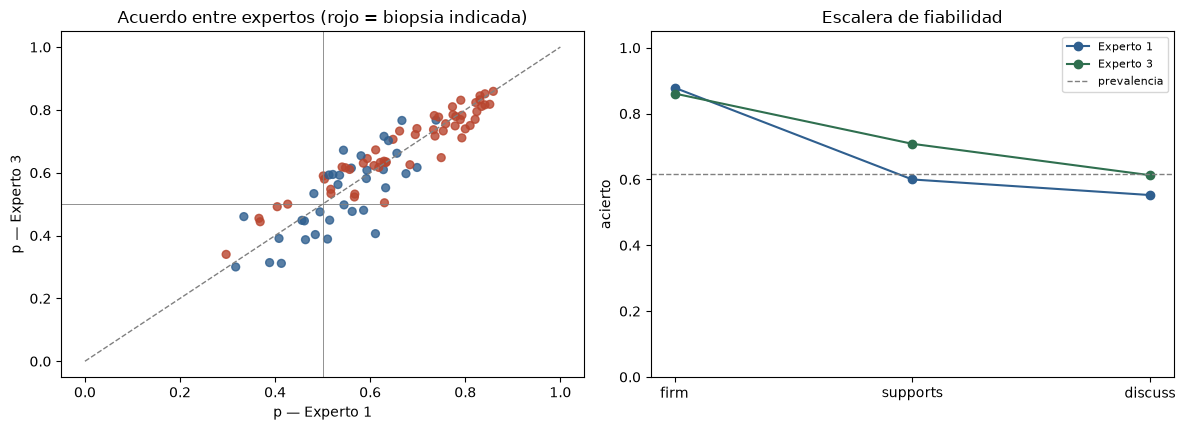

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(o1["p_ensemble"], o3["p_ensemble"], c=np.where(y == 1, "#b8452e", "#2f5f8f"), s=32, alpha=.8)
axes[0].plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
axes[0].axhline(.5, c="grey", lw=.6); axes[0].axvline(.5, c="grey", lw=.6)
axes[0].set_xlabel("p — Experto 1"); axes[0].set_ylabel("p — Experto 3")
axes[0].set_title("Acuerdo entre expertos (rojo = biopsia indicada)")

for name, o, c in [("Experto 1", o1, "#2f5f8f"), ("Experto 3", o3, "#2f6f4f")]:
    t = pd.DataFrame(ladder_table(y, o["p_ensemble"].values, o["sigma_total"].values))
    axes[1].plot(t["rung"], t["accuracy"], "o-", c=c, label=name)
axes[1].axhline(y.mean(), ls="--", c="grey", lw=1, label="prevalencia")
axes[1].set_ylabel("acierto"); axes[1].set_ylim(0, 1.05)
axes[1].set_title("Escalera de fiabilidad"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Dónde discrepan, y quién acierta cuando discrepan

Este es el dato que un deliberador necesita: cuando los dos expertos se
contradicen, ¿hay alguno sistemáticamente mejor, o el desacuerdo es señal de que
el caso es genuinamente difícil?

In [8]:
d1 = (o1["p_ensemble"] >= .5).astype(int); d3 = (o3["p_ensemble"] >= .5).astype(int)
dis = d1 != d3
print(f"Casos en desacuerdo: {dis.sum()} de {len(y)} ({dis.mean():.1%})")
if dis.sum():
    print(f"  acierta el Experto 1: {(d1[dis] == y[dis]).sum()}")
    print(f"  acierta el Experto 3: {(d3[dis] == y[dis]).sum()}")
    print(f"\n  acierto medio en casos de ACUERDO   : {(d1[~dis] == y[~dis]).mean():.3f}")
    print(f"  acierto medio en casos de DESACUERDO: {(d1[dis] == y[dis]).mean():.3f} (E1) / "
          f"{(d3[dis] == y[dis]).mean():.3f} (E3)")

Casos en desacuerdo: 7 de 91 (7.7%)
  acierta el Experto 1: 1
  acierta el Experto 3: 6

  acierto medio en casos de ACUERDO   : 0.726
  acierto medio en casos de DESACUERDO: 0.143 (E1) / 0.857 (E3)


## 6. Importancia y traducción al formulario del reto

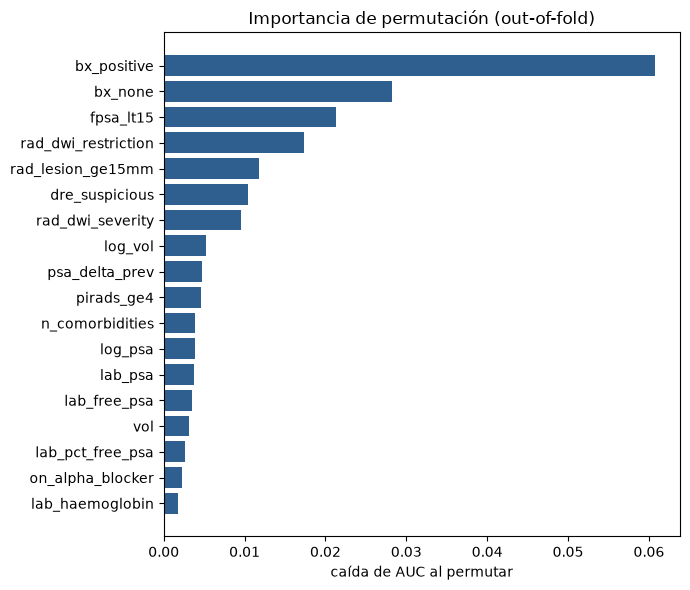

,Experto 1,Experto 3
bx,decisive,decisive
fh,not_used,not_used
age,noted,not_used
dre,noted,noted
psa,noted,noted
vol,noted,noted
psad,noted,noted
cspca,noted,not_used
pirads,noted,important
comorbidity,important,noted


In [9]:
imp = pd.read_csv(ART / "expert_three_importance.csv").head(18)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(imp["feature"][::-1], imp["auc_drop"][::-1], color="#2f5f8f")
ax.set_xlabel("caída de AUC al permutar"); ax.set_title("Importancia de permutación (out-of-fold)")
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    "Experto 1": weights_from_importance(e1.importance, e1.blocks),
    "Experto 3": weights_from_importance(e3.importance, e3.blocks),
}))

## 7. Salida completa sobre un caso

In [10]:
rep = e3.report([labelled[3]])[0]
print(json.dumps(rep.to_expert_payload(), indent=2, ensure_ascii=False))

{
  "case_id": "PT-pseudo_033f1a8e1503",
  "expert": "expert_three_fusion",
  "blocks": "ABD",
  "decision": "yes",
  "probability": 0.8726,
  "interval_95": [
    0.7173,
    1.0
  ],
  "uncertainty": {
    "epistemic_model": 0.0792,
    "epistemic_missing": 0.0008,
    "epistemic_total": 0.0792,
    "aleatoric_entropy": 0.5502
  },
  "evidence_completeness": 1.0,
  "reliability_tier": "firm",
  "confidence": "clear",
  "variable_weights": {
    "bx": "decisive",
    "fh": "not_used",
    "age": "not_used",
    "dre": "noted",
    "psa": "noted",
    "vol": "noted",
    "psad": "noted",
    "cspca": "not_used",
    "pirads": "important",
    "comorbidity": "noted"
  },
  "reveal_sequence": [
    "radiology_report",
    "laboratory_results"
  ],
  "top_features": [
    {
      "feature": "bx_positive",
      "importance": 0.0608
    },
    {
      "feature": "bx_none",
      "importance": 0.0282
    },
    {
      "feature": "fpsa_lt15",
      "importance": 0.02132
    },
    {
      "